## Project Scope: FIFA 20 Players Dataset Analysis and Clustering

### `Goal:`

The goal of this project is to analyze the FIFA 20 players dataset and cluster them based on their attributes to gain a better understanding of their playing styles and contributions to the game.

### `Objectives:`

- Conduct exploratory data analysis (EDA) on the FIFA 20 players dataset to uncover patterns and insights
- Develop a model to cluster the players based on their attributes
- Evaluate and interpret the results of the clustering model
- Present findings in a comprehensive report with visualizations and explanations

### `Deliverables:`

- Exploratory data analysis report
- Clustering model report
- Final report with results, interpretations, and recommendations
- Visualizations and explanations to accompany the reports

In [63]:
!pip install yellowbrick

In [1]:
## Importing packages needed
import pandas as pd
import numpy as np
from scipy import stats

#visualisation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.graph_objs as go
from yellowbrick.cluster import KElbowVisualizer
from PIL import Image
from IPython.display import display

#data processing
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

#clustering model
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import fcluster

#performance metrics
from sklearn.metrics import silhouette_score, silhouette_samples

#warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
## Importing Dataset
df= pd.read_csv('players_20.csv')
df.sample(3)

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
3290,246419,https://sofifa.com/player/246419/yari-verschae...,Y. Verschaeren,Yari Verschaeren,17,2001-07-12,172,63,Belgium,RSC Anderlecht,...,58+2,55+2,55+2,55+2,58+2,54+2,45+2,45+2,45+2,54+2
4931,216449,https://sofifa.com/player/216449/tomas-martins...,Tomás Podstawski,Tomás Martins Podstawski,24,1995-01-30,182,74,Portugal,Pogoń Szczecin,...,65+2,69+2,69+2,69+2,65+2,65+2,68+2,68+2,68+2,65+2
4266,205970,https://sofifa.com/player/205970/jed-wallace/2...,J. Wallace,Jed Wallace,25,1994-03-26,178,70,England,Millwall,...,60+2,57+2,57+2,57+2,60+2,58+2,51+2,51+2,51+2,58+2


### Basic Checks

In [3]:
df.shape

(18278, 104)

In [4]:
# filtering out early on columns which would be irrelevant for this project
irrelvant_cols=['sofifa_id', 'player_url', 'long_name', 'dob', 'real_face', 'body_type', 'player_tags','loaned_from', 'joined',
                'team_jersey_number', 'nation_jersey_number', 'contract_valid_until', 'player_traits']
#dropping irrelevant columns
fifa= df.drop(irrelvant_cols, axis=1)
fifa.shape

(18278, 91)

### The attributes used in the project are:
Name: Name of the player.

Age: Age of the player.

Height: Height of the player in inches (transformed to centimeters in preprocessing).

Overall: General performance quality and value of the player representing the key positional skills and international reputation rated between 1-99. Overall attribute is used only in preprocessing and discussion stages because using it in modelling could lead to domination by this feature. The aim of the project is not basically sort and categorize the players using their overall talent and international reputation, but to cluster them based on using their whole skillset.

Potential: Maximum Overall rating expected to be reached by a player in the top of his career rated between 1-99.

PreferredFoot: Right or Left. Label encoder is applied as 0 for left and 1 for right.

WeakFoot: Represents how well a player uses his weak foot (e.g. left for righties) rated between 1 to 5.

WorkRate: Degree of the effort the player puts in terms of attack and defense rated as low, medium and high. This feature is divided into two new features as AttackWorkRate and DefenseWorkRate. Besides, label encoder is applied as 0 for low, 0.5 for medium and 1 for high.

Position: Position of the players on the pitch which determines their roles and responsibilities in the team. Forward positions in the football and FIFA 20 can be grouped as striker (ST: center striker, RS: right striker, LS: left striker), forward (CF: center forward, RF: right forward, LF: left forward) and winger (RW: right winger, LW: left winger). The word, forward, is used both as a general term and a special position. Strikers are positioned in front of forwards and wingers and very closed to the opposing goal. Their main responsibilities are attacking and scoring goals, that’s why their ball control, shooting and finishing skills are expected to be well. Center forwards are positioned right behind the strikers. They are expected to receive balls from the others and score assists to the others or goals. In addition to the skills expected from strikers, they have to be good at passing. Right forwards and left forwards are positioned at the right and left of the center forwards with the same expectations. Wingers are positioned near the touchlines to create chances for strikers and forwards from the right and left side of the field by breakthrough and crosses and to score goals. They are expected to be good at dribbling, acceleration, passing and crossing. Positions are used only in preprocessing and discussion stages.

ST: Positional skill. Player’s general ability when playing in ST position rated between 1-99.

RS: Positional skill. Player’s general ability when playing in in RS position rated between 1-99.

LS: Positional skill. Player’s general ability when playing in in LS position rated between 1-99.

CF: Positional skill. Player’s general ability when playing in in CF position rated between 1-99.

RF: Positional skill. Player’s general ability when playing in in RF position rated between 1-99.

LF: Positional skill. Player’s general ability when playing in in LF position rated between 1-99.

RW: Positional skill. Player’s general ability when playing in in RW position rated between 1-99.

LW: Positional skill. Player’s general ability when playing in in LW position rated between 1-99.

Crossing: Crossing skill of the player rated between 1-99. Cross is a long-range pass from wings to center.

Finishing: Finishing skill of the player rated between 1-99. Finishing in football refers to finish an attack by scoring a goal.

HeadingAccuracy: Player’s accuracy to pass or shoot by using his head rated between 1-99.

ShortPassing: Player’s accuracy for short passes rated between 1-99.

LongPassing: Player’s accuracy for long passes rated between 1-99.

Dribbling: Dribbling skill of the player rated between 1-99. Dribbling is carrying the ball without losing while moving in one particular direction.

SprintSpeed: Speed rate of the player rated between 1-99.

Acceleration: Shows how fast a player can reach his maximum sprint speed rated between 1-99.

FKAccuracy: Player’s accuracy to score free kick goals rated between 1-99.

BallControl: Player’s ability to control the ball rated between 1-99.

Balance: Player’s ability to remain steady while running, carrying and controlling the ball rated between 1-99.

ShotPower: Player’s strength level of shooting the ball rated between 1-99.

Jumping: Player’s jumping skill rated between 1-99.

Penalties: Player’s accuracy to score goals from penalty rated between 1-99.

Strength: Physical strength of the player rated between 1-99.

Agility: Gracefulness and quickness of the player while controlling the ball rated between 1-99.

Reactions: Acting speed of the player to what happens in his environment rated between 1-99.

Aggression: Aggression level of the player while pushing, pulling and tackling rated between 1-99.

Positioning: Player’s ability to place himself in the right position to receive the ball or score goals rated between 1-99.

Vision: Player’s mental awareness about the other players in the team for passing rated between 1-99.

Volleys: Player’s ability to perform volleys rated between 1-99.

LongShots: Player’s accuracy of shoots from long distances rated between 1-99.

Stamina: Player’s ability to sustain his stamina level during the match rated between 1-99. Players with lower stamina get tired fast.

Composure: Player’s ability to control his calmness and frustration during the match rated between 1-99.

Curve: Player’s ability to curve the ball while passing or shooting rated between 1-99.

Interceptions: Player’s ability to intercept the ball while opposite team’s players are passing rated between 1-99. It is a defensive skill.

StandingTackle: Player’s ability to perform tackle (take the ball from the opposite player) while standing rated between 1-99. It is a defensive skill.

SlidingTackle: Player’s ability to perform tackle by sliding rated between 1-99. It is a defensive skill.

Marking: Player’s ability to apply strategies to prevent opposing team from taking the ball rated between 1-99. It is a defensive skill.

#### Checking Duplicate Values

In [5]:
fifa.duplicated().sum()

0

In [6]:
fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Data columns (total 91 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   short_name                  18278 non-null  object 
 1   age                         18278 non-null  int64  
 2   height_cm                   18278 non-null  int64  
 3   weight_kg                   18278 non-null  int64  
 4   nationality                 18278 non-null  object 
 5   club                        18278 non-null  object 
 6   overall                     18278 non-null  int64  
 7   potential                   18278 non-null  int64  
 8   value_eur                   18278 non-null  int64  
 9   wage_eur                    18278 non-null  int64  
 10  player_positions            18278 non-null  object 
 11  preferred_foot              18278 non-null  object 
 12  international_reputation    18278 non-null  int64  
 13  weak_foot                   182

### Dealing with Missing Values

In [7]:
gk_attribute_cols= ['gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning']
fifa[gk_attribute_cols]=fifa[gk_attribute_cols].fillna(0)
fifa[fifa['team_position']=='GK'].head(3)

,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
3,J. Oblak,26,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,M. ter Stegen,27,187,85,Germany,FC Barcelona,90,93,67500000,250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,Alisson,26,191,91,Brazil,Liverpool,89,91,58000000,155000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`As we can see, the attacking and defending attributes for all goalkeepers are missing. We will replace these missing values with 0.`

In [8]:
no_goalkeeper=['pace','shooting','passing','dribbling','defending','physic',
        'ls','st','rs','lw','lf','cf','rf','rw','lam','cam','ram','lm','lcm','cm',
        'rcm','rm','lwb','ldm','cdm','rdm','rwb','lb','lcb','cb','rcb','rb']

for index in fifa.index:
    if 'GK' in fifa.loc[index, 'player_positions']:
        for col in no_goalkeeper:
            if np.isnan(fifa.loc[index, col]):
                fifa.loc[index, col]=0
                
fifa[fifa['team_position']=='GK'].head()

,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
3,J. Oblak,26,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,...,0,0,0,0,0,0,0,0,0,0
6,M. ter Stegen,27,187,85,Germany,FC Barcelona,90,93,67500000,250000,...,0,0,0,0,0,0,0,0,0,0
13,Alisson,26,191,91,Brazil,Liverpool,89,91,58000000,155000,...,0,0,0,0,0,0,0,0,0,0
14,De Gea,28,192,82,Spain,Manchester United,89,90,56000000,205000,...,0,0,0,0,0,0,0,0,0,0
25,Ederson,25,188,86,Brazil,Manchester City,88,91,54500000,185000,...,0,0,0,0,0,0,0,0,0,0


#### Cross checking missing values

In [9]:
fifa.isna().sum().sort_values(ascending=False)/fifa.shape[0]*100

nation_position       93.839589
release_clause_eur     7.101433
team_position          1.313054
short_name             0.000000
goalkeeping_diving     0.000000
                        ...    
gk_positioning         0.000000
gk_speed               0.000000
gk_reflexes            0.000000
gk_kicking             0.000000
rb                     0.000000
Length: 91, dtype: float64

`nation_position column contained 94% missing values. So we will drop the complete column`

In [10]:
# deleting column 'nation_position'
fifa.drop('nation_position', axis=1, inplace=True)

`We will replace missing values in team_position column by 'Not Given'`

In [11]:
fifa['team_position']=fifa['team_position'].fillna('Not Given')

In [12]:
fifa.isna().sum().sort_values(ascending=False)/fifa.shape[0]

release_clause_eur          0.071014
short_name                  0.000000
defending_sliding_tackle    0.000000
rs                          0.000000
st                          0.000000
                              ...   
gk_positioning              0.000000
gk_speed                    0.000000
gk_reflexes                 0.000000
gk_kicking                  0.000000
rb                          0.000000
Length: 90, dtype: float64

Now only one column is remained with the missing value. We do not want to directly drop the row as we could loose data on some important players. So let us wait for the EDA part and impute the missing value

## Curating datatype

If we look at the last 26 columns, they represent positional attributes of the players. But they are given in string format. We will round off these attribute to nearest integer. To perform this action, we will create a function str_to_int which will transform the string to nearest interger

In [13]:
#curating following columns
fifa.iloc[:3,64:]

,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,89+2,89+2,89+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,84+3,84+3,84+3,90+3,89+3,89+3,89+3,90+3,90+3,90+3,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3


In [15]:
def str_to_int(x):
   
   new= int(str(x).split('+')[0]) 

   return new

In [16]:
# columns to change the datatypes
columns= ['ls','st', 'rs','lw','lf','cf','rf','rw','lam','cam','ram','lm','lcm','cm','rcm','rm','lwb','ldm','cdm','rdm','rwb','lb','lcb','cb','rcb','rb']

for col in columns:
    fifa[col]=fifa[col].apply(str_to_int)

fifa.head(3)

,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,L. Messi,32,170,72,Argentina,FC Barcelona,94,94,95500000,565000,...,68,66,66,66,68,63,52,52,52,63
1,Cristiano Ronaldo,34,187,83,Portugal,Juventus,93,93,58500000,405000,...,65,61,61,61,65,61,53,53,53,61
2,Neymar Jr,27,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,...,66,61,61,61,66,61,46,46,46,61


## Task 1

## EDA

### Univariate Analysis:

#### Height, Weight and Age Distribution


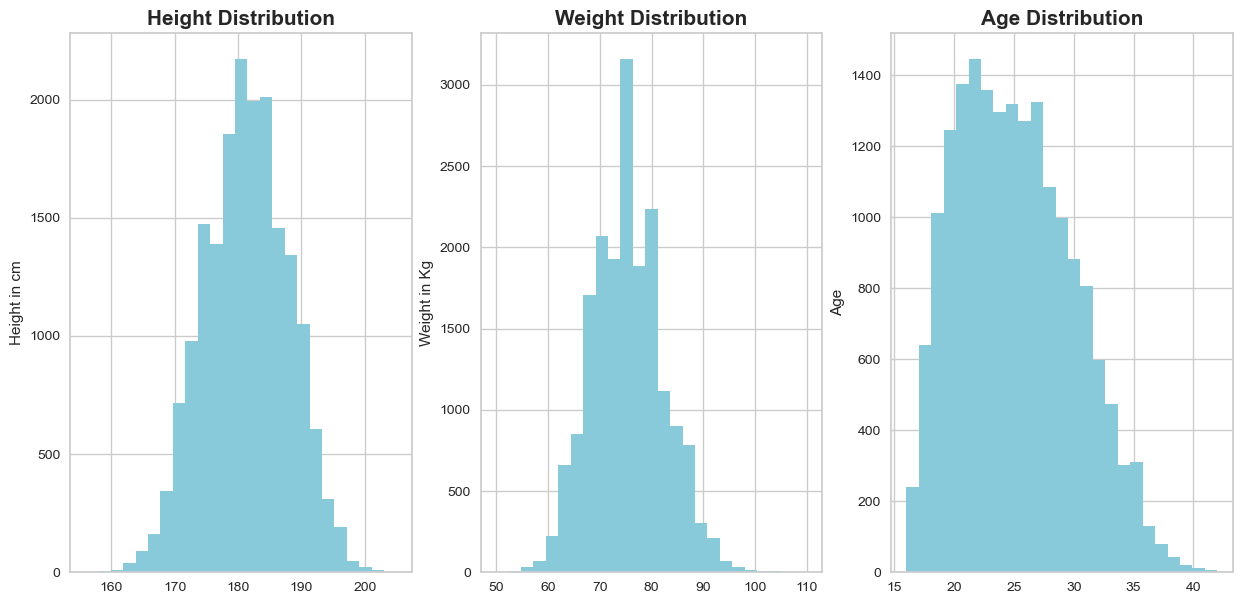

In [17]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
plt.hist(fifa['height_cm'], bins=25, color='c')
plt.ylabel('Height in cm')
plt.title('Height Distribution'.title(), fontsize=15, fontweight="bold")

plt.subplot(1,3,2)
plt.hist(fifa['weight_kg'], bins=25, color='c')
plt.ylabel('Weight in Kg')
plt.title('Weight Distribution'.title(), fontsize=15, fontweight="bold")

plt.subplot(1,3,3)
plt.hist(fifa['age'], bins=25, color='c')
plt.ylabel('Age')
plt.title('Age Distribution'.title(), fontsize=15, fontweight="bold");

- All 3 attributes appear to follow normal distribution
- Heights of most of the players gathered around 175 cm to 185 cm. Highest peak is seen at 180 cm.
- Most players in the fifa dataset weighed around 70 kg to 85kg. Most number of players has weight of 75 kg.
- Age distribution appeared to be slightly right skewed. Players' age is spread a bit more on the right side than the left one. Most number of players fell into age between 18 to 30 years.

### Task 3 - 1


#### Player count based on Nationality


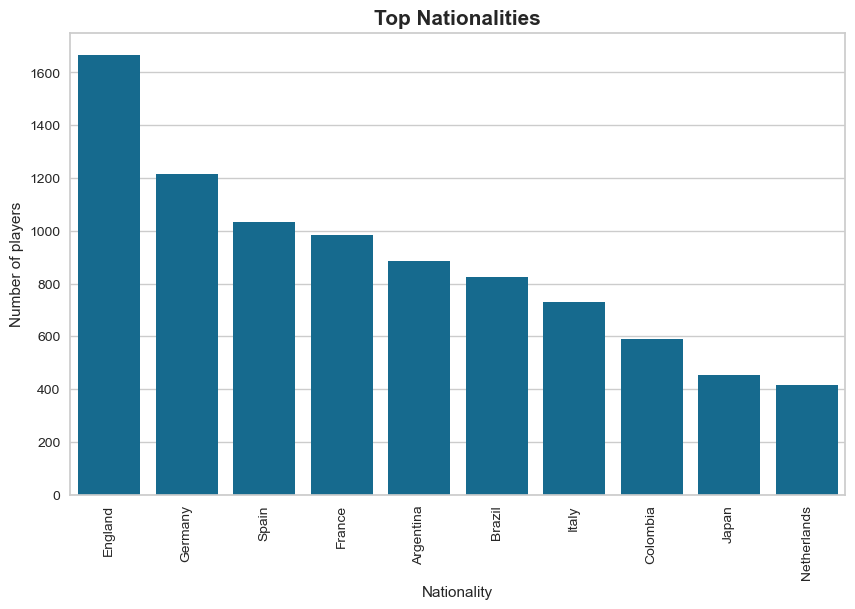

In [18]:
top_nationalities=fifa.nationality.value_counts(ascending=False)[:10]

plt.figure(figsize=(10,6))
sns.barplot(top_nationalities)
plt.xlabel('Nationality')
plt.ylabel('Number of players')
plt.xticks(rotation=90)
plt.title('Top nationalities'.title(), fontsize=15, fontweight="bold");

- England has the highest percentage of players in the dataset at 9.12%.
- The top 10 nationalities together account for more than 45% of the players in the dataset, indicating a concentration of players from a relatively small number of countries.
- European countries dominate the top 10, with six of them being from Europe.
- South American countries are also well represented in the top 10, with Argentina and Brazil being in the top 5.
- Japan is the only Asian country in the top 10, indicating a relatively smaller presence of players from Asia in the dataset.
- The differences in percentages between the top 10 countries are relatively small, with the highest percentage (England) being only about 6 - percentage points higher than the 10th highest percentage (Netherlands). This suggests a relatively even distribution of players across the top 10 countries in the dataset.

#### Value, Wage and Release Clause of Players


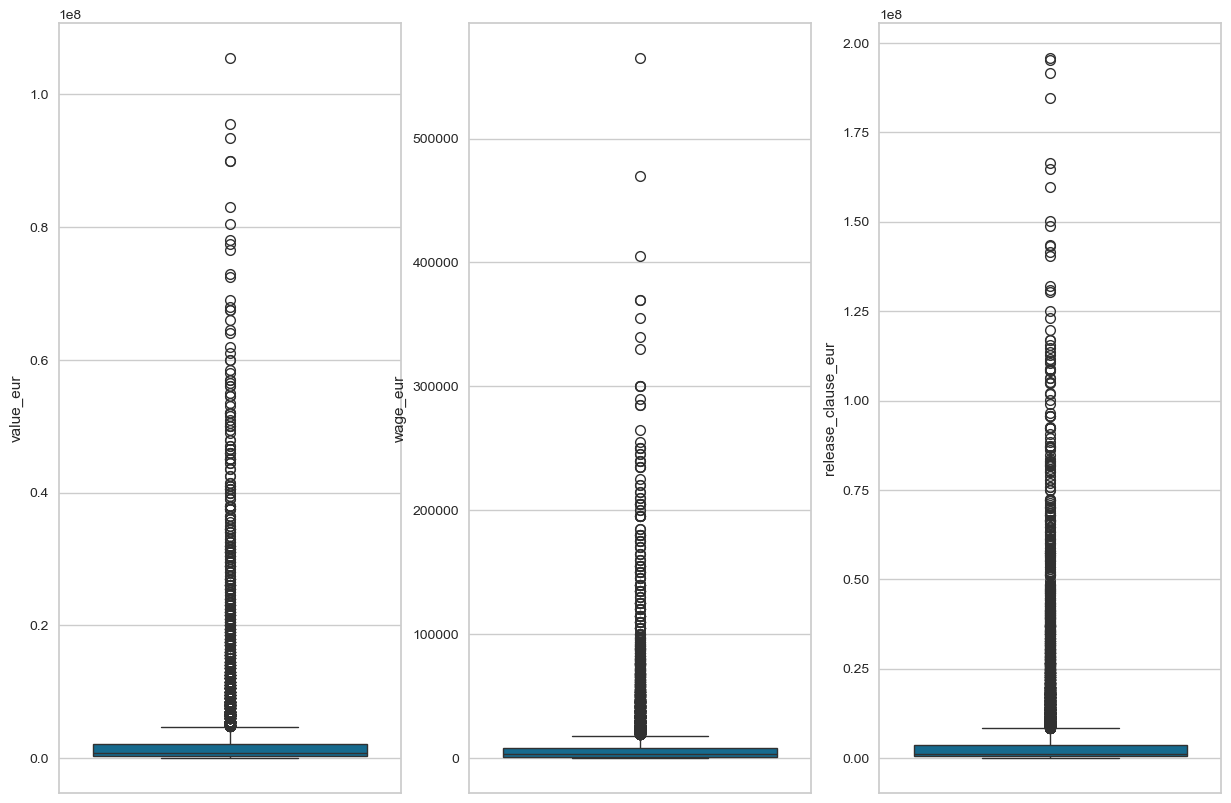

In [19]:
plt.figure(figsize=(15,10))

plt.subplot(1,3,1)
sns.boxplot(y='value_eur',data=fifa)

plt.subplot(1,3,2)
sns.boxplot(y='wage_eur',data=fifa)

plt.subplot(1,3,3)
sns.boxplot(y='release_clause_eur',data=fifa);

- There are players who have zero market value, wage, and/or release clause. It appears as values are unavailable or an error in data entry because it does not make much sense that many players will play for free with zero market value
- The distributions of all three attributes are positively skewed, with a long tail towards the higher values.
- The maximum values for all three attributes are significantly higher than their respective third quartiles, indicating the presence of outliers with extremely high values.
- The median wage is much lower than the median market value and median release clause, indicating that players receive a relatively small portion of their market value as wage.

#### Preferred Foot


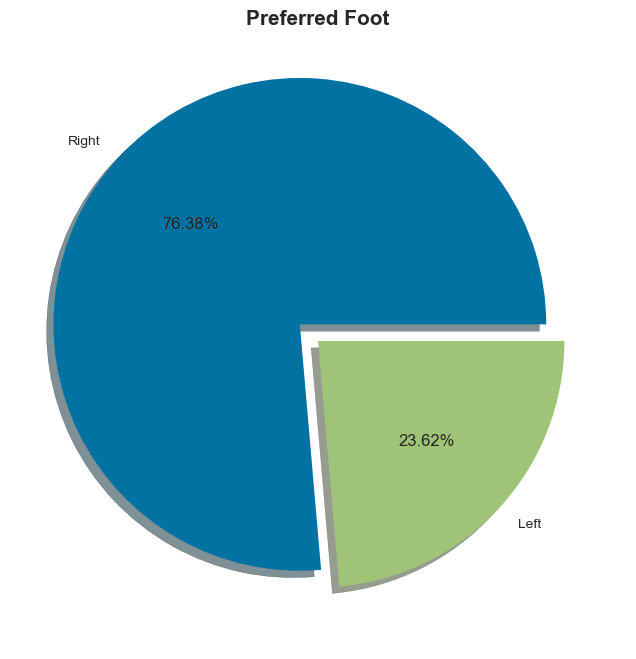

In [20]:
foot=fifa.preferred_foot.value_counts()
plt.figure(figsize=(8,8))
plt.pie(foot, labels=foot.keys(), autopct='%.2f%%', explode=[0.1,0], shadow=True)
plt.title('Preferred foot'.title(), fontsize=15, fontweight="bold");

- The majority of players in the FIFA dataset have a preferred foot of Right, with a count of 13960.
- The number of players with a preferred foot of Left is much smaller, with a count of only 4318 which is equivalent to 23.62% of the total players.
- This suggests that the majority of football players are more comfortable playing with their right foot, which could be due to a variety of factors such as being naturally right-footed or receiving more training and practice on their right side.

#### Overall and Potential Attributes


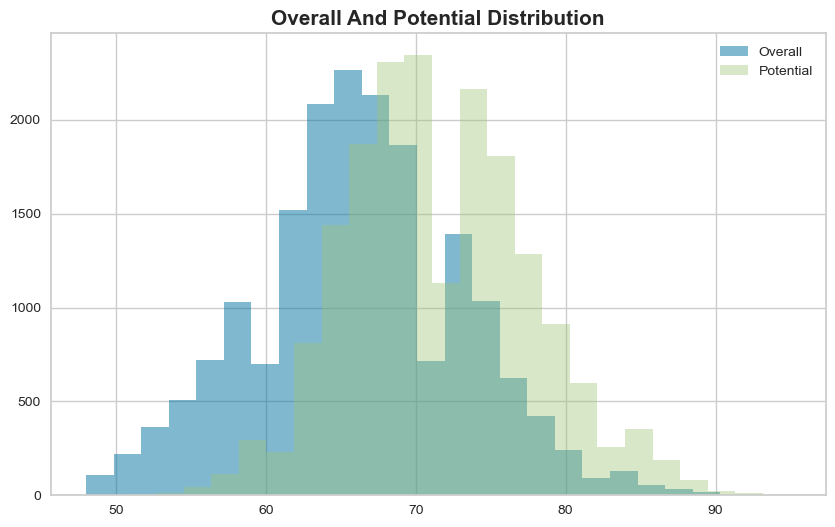

In [21]:
plt.figure(figsize=(10,6))
plt.hist(fifa['overall'], bins=25, alpha=0.5, label='Overall')
plt.hist(fifa['potential'], bins=25, alpha=0.4, label='Potential')
plt.legend()
plt.title('Overall and Potential Distribution'.title(), fontsize=15, fontweight="bold");

- Potential attribute is distributed on the right side as compared to Overall attributes. This suggests that many plates are players are yet to level thier potential.
- Overall attribute is gathered more between 60 to 70, whereas, most of the players have potential to be between 65 to 75.

### Bivariate Analysis:


#### Heights vs Weights


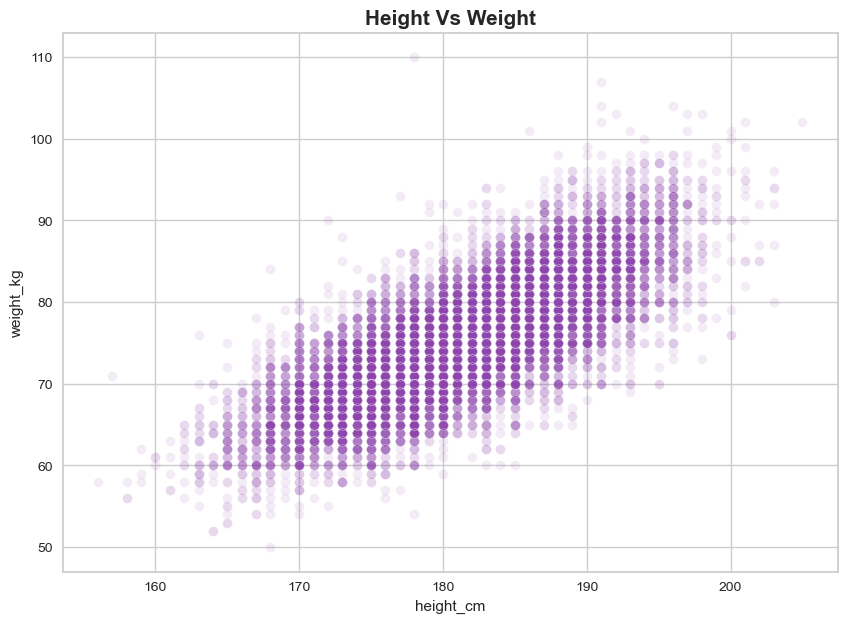

In [22]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='height_cm', y='weight_kg', data=fifa, alpha=0.1, color="#8e44ad")
plt.title('Height vs Weight'.title(), fontsize=15, fontweight="bold");

`Players weights are positively correlated with their heights. In other words, players with more heights tend to have more weights.`

## Task 3 - 2

#### Age vs other attributes

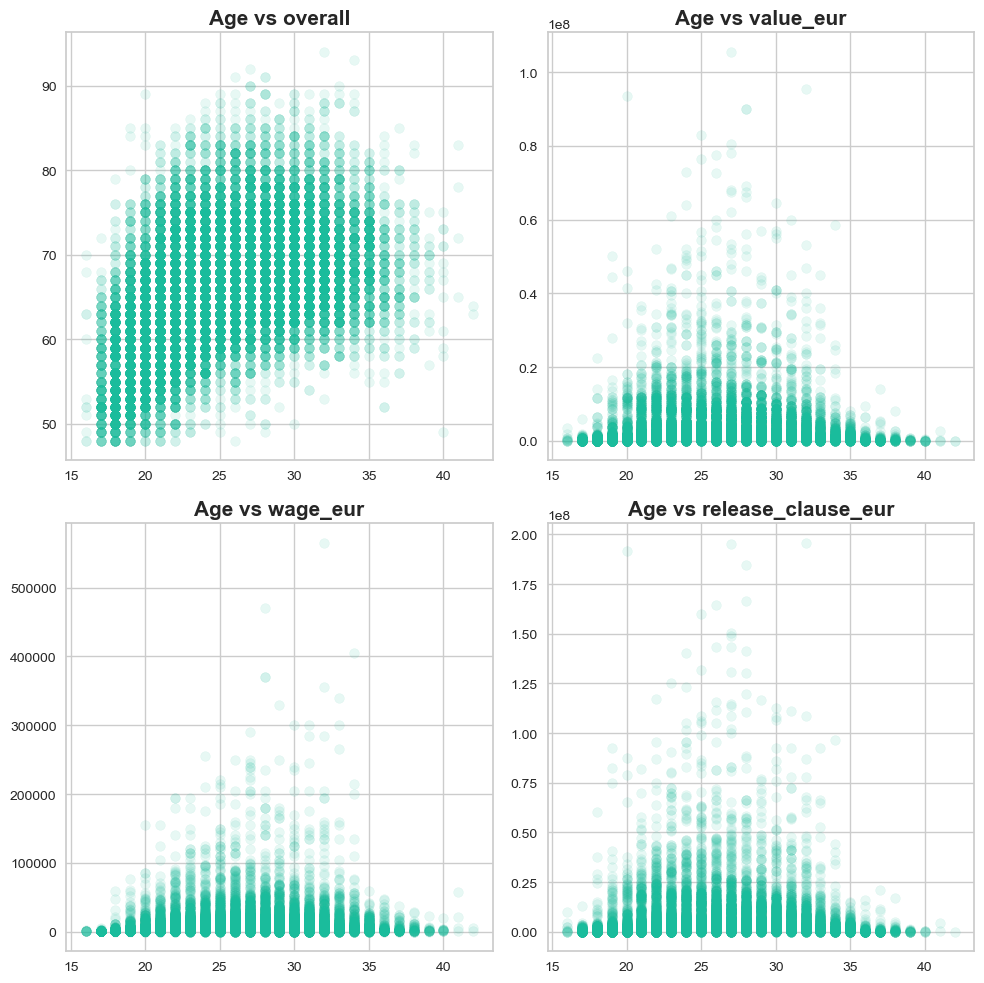

In [23]:
# columns to compare with Age

columns=['overall', 'value_eur', 'wage_eur', 'release_clause_eur']

fig, ax=plt.subplots(2,2, figsize=(10,10))

for col, ax in zip(columns, ax.flatten()):
    ax.scatter(fifa['age'], fifa[col], alpha=0.1, color="#1abc9c")
    ax.set_title('Age vs {}'.format(col), fontsize=15, fontweight="bold")
plt.tight_layout()

- For Age vs Overall, the general trend is upward. It insuinitate that players who spent more years playing on the pitch gained more overall rating. However, the trend is moderate. Some players show higher overall ratings than many players despite being younger and vice-versa is true for some players as well. Surely, natural talent plays a role in players' development. Looking at Haaland and Mbappe, we need not ask for proof.
- When attribute 'age' is plotted against players values, wage and release clause, we have observed that values are normally distributed across age. Value, wage and Release clause is higher for player who fall in age group between 21 years and 34 years with tails on both sides. This means that players value, wage and release clause in lower at the begining and end of the their career.
- By comparing age with other attributes, we can observe that player reaches his prime in the mid of 30. skills and earned value for any player is lesser at beginning and end of his career and maximum at around 25-30 years of his age.

#### Who are the most valued players?

In [24]:
players=fifa[fifa['overall']>=65]

print('fifa', fifa.shape)
print('players', players.shape)

fifa (18278, 90)
players (11020, 90)


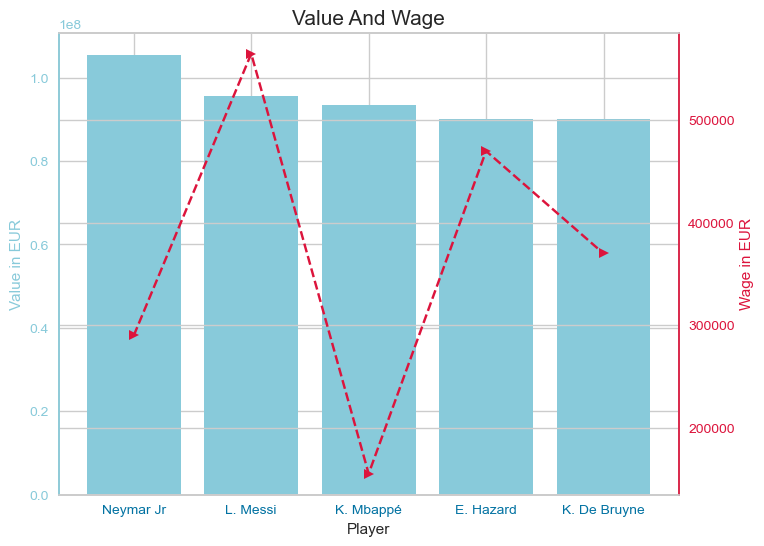

In [25]:
most_valued= players[['short_name', 'value_eur', 'wage_eur']].sort_values('value_eur', ascending=False).head(5)

fig, ax1 = plt.subplots(figsize=(8,6))
ax1.bar(most_valued.short_name, most_valued.value_eur, color= 'c', label='value')
ax1.set_ylabel('Value in EUR', color='c')
ax1.tick_params(axis='y', labelcolor= 'c')
ax1.set_xticklabels(labels= most_valued.short_name)

#creating twin y axis as ax2
ax2 = ax1.twinx()

ax2.plot(most_valued.short_name, most_valued.wage_eur, c='crimson', linestyle='--', marker='>', label= 'wage')
ax2.set_ylabel('Wage in EUR', color='crimson')
ax2.tick_params(axis='y', labelcolor= 'crimson')

ax1.set_xlabel('Player')
ax1.tick_params(axis='x', labelcolor= "b")
plt.title('Value and Wage'.title(), fontsize=15)

ax2.spines['left'].set_color('c')
ax2.spines['right'].set_color('crimson');

The results are in, and the most valued FIFA 20 player is none other than Neymar Jr! With a whopping value of 105.5 million euros and a weekly wage of 290,000 euros, Neymar Jr is certainly living up to his reputation as one of the best players in the world.

But that's not all - coming in at a close second is none other than Lionel Messi, valued at 95.5 million euros and earning a weekly wage of 565,000 euros. Messi is widely regarded as one of the greatest footballers of all time, and it's no surprise to see him near the top of the list.

In third place is Kylian Mbappé, the young French superstar who has taken the football world by storm. Valued at 93.5 million euros and earning a weekly wage of 155,000 euros, Mbappé is certainly one to watch for the future.

Fourth and fifth place are occupied by two of the Premier League's finest - Eden Hazard and Kevin De Bruyne. Hazard, who recently made the switch from Chelsea to Real Madrid, is valued at 90 million euros and earns a weekly wage of 470,000 euros. De Bruyne, who has been in sensational form for Manchester City, is also valued at 90 million euros but earns a slightly lower weekly wage of 370,000 euros.

It's fascinating to see the differences in value and wage among these top players. While Neymar Jr is the most valued player, he earns a lower weekly wage than Lionel Messi, who is valued slightly lower. Similarly, Kevin De Bruyne is valued the same as Eden Hazard, but earns a lower weekly wage. These differences could reflect a variety of factors, such as the players' performance on the pitch, their age, and their marketability.

One notable fact to note is that Neymar Jr's value is more than double that of his Paris Saint-Germain teammate, Kylian Mbappé. This could reflect Neymar Jr's experience and track record in the sport, as well as his marketability off the pitch.

Overall, the list of the most valued players in FIFA 20 is a fascinating glimpse into the world of professional football. These players have worked hard to achieve their success, and it's exciting to see how their careers will develop in the years to come.

## Task 3 - 3

#### Which type of offensive players tends to get paid the most?
Offensive players are those players on the team that are primarily responsible for scoring goals and creating scoring opportunities for their team. These players typically play in positions such as:

Striker (ST): The striker is the player who is responsible for scoring goals. They play at the front of the team and are usually the most forward of the offensive players. They rely on speed, agility, and precision to shoot the ball into the goal.

Forward (F): The forward is similar to the striker, but may play a slightly different role in the team. They also work to create scoring opportunities, and are often involved in passing the ball to other offensive players.

Attacking Midfielder (CAM): The attacking midfielder plays in the middle of the field and is responsible for creating scoring opportunities for the team. They often use their technical skills, passing ability, and vision to create openings for their team.

Winger (RW/LW): The winger is a player who plays on the sides of the field and is responsible for creating chances to score goals. They use their speed and dribbling ability to move past defenders and cross the ball into the box.

Forward/Attacking Midfielder (CF): The forward/attacking midfielder, also known as a "false nine," is a position that combines the roles of the striker and the attacking midfielder. They often play behind the striker and are responsible for both creating and scoring goals.

Overall, offensive players are crucial to any football team's success, as they are responsible for creating and scoring goals, and putting pressure on the opposing team's defense.

In [27]:
offensive_pos= ['RW', 'LW', 'CAM', 'ST', 'CF', 'LS', 'RAM', 'RS', 'RF', 'LF', 'LAM']

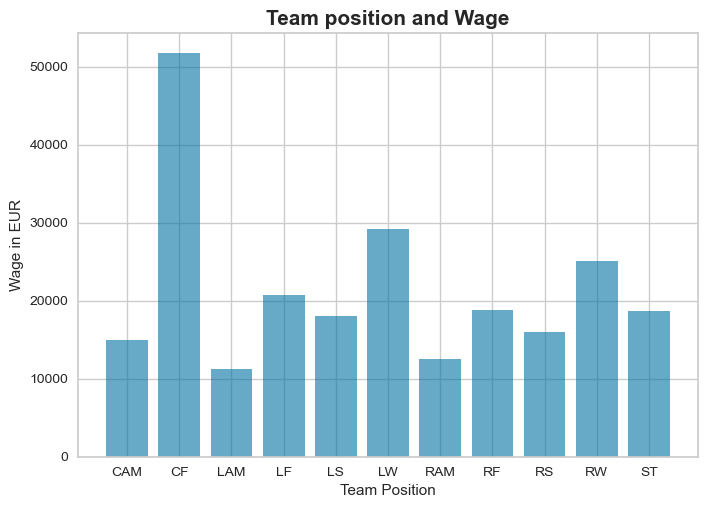

In [28]:
off_players= players[players['team_position'].isin(offensive_pos)]
off_avg= off_players.groupby('team_position')['wage_eur'].mean()
plt.bar(off_avg.keys(), off_avg.values, alpha=0.6)
plt.xlabel('Team Position')
plt.ylabel('Wage in EUR')
plt.title('Team position and Wage', fontsize=15, fontweight='bold');

After analyzing the data on player wages in FIFA, we can see that the position of center forward (CF) tends to get paid the most among offensive players, with an average wage of 51,714 euros per week. This position is responsible for leading the attack and scoring goals, so it's not surprising that they are paid a premium.

Other positions that tend to have high wages include the left wing (LW) and right wing (RW), with average wages of 29,188 and 25,052 euros per week respectively. These positions are responsible for creating chances and providing crosses for the center forward to score goals.

Interestingly, the position of striker (ST), which is traditionally considered the most important offensive position, has a lower average wage compared to center forward. The average wage for strikers is 18,705 euros per week, which is lower than the wages for CF, LW, and RW.

One interesting fact is that the data shows that the position of left attacking midfielder (LAM) has the lowest average wage among offensive positions, with a weekly wage of just 11,285 euros. This position is responsible for creating chances from the left side of the field, but it seems that they are not as highly valued in terms of wages compared to other offensive positions.

Overall, this data shows that the position of center forward tends to be the most highly paid among offensive players in FIFA, which is not surprising given their role in scoring goals and leading the attack.

### Data Preprocessing

For clustering model, we will select players with overall rating more than 80. This is because players with an overall rating of 80 or higher are generally considered to be top-performing players in the game. These players are likely to have high levels of skill across various attributes, such as dribbling, passing, shooting, and physical attributes.

By selecting only high-rated players for clustering, you are more likely to identify clusters of players who possess exceptional skills in one or more areas of the game. This can be valuable for identifying patterns in player performance and for making strategic decisions when selecting players for a team.

Additionally, selecting only high-rated players reduces the noise in the dataset and can improve the accuracy of the clustering model. This is because lower-rated players may have a wider range of skill levels, which can make it harder to identify meaningful clusters.



In [29]:
train_fifa=fifa[fifa['overall']>80]

#### Missing Value Imputation

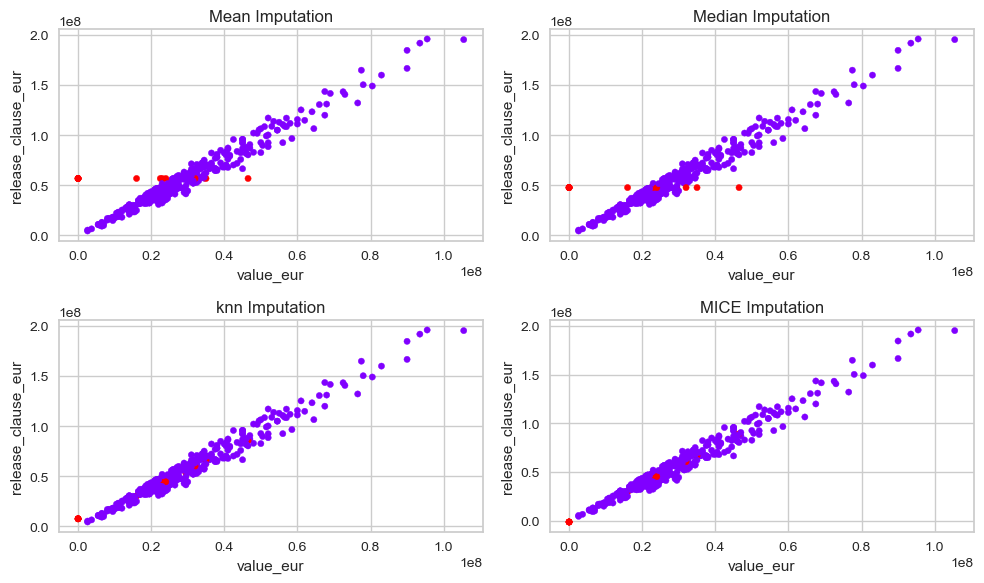

In [30]:
# filtering out numerical data
fifa_cat_list=list(train_fifa.select_dtypes('object').columns)
fifa_num=train_fifa.drop(columns=fifa_cat_list)

# mean imputation
df_mean = fifa_num.copy()
mean_imputer = SimpleImputer(strategy = "mean")
df_mean.iloc[:,:] = mean_imputer.fit_transform(df_mean)

# median imputation
df_median =fifa_num.copy()
median_imputer = SimpleImputer(strategy = "median")
df_median.iloc[:,:] = median_imputer.fit_transform(df_median)

# KNN imputation
df_knn = fifa_num.copy()
knn_imputer = KNNImputer()
df_knn.iloc[:,:]= knn_imputer.fit_transform(df_knn)

# MICE imputation
df_mice= fifa_num.copy()
mice_imputer = IterativeImputer()
df_mice.iloc[:,:]= mice_imputer.fit_transform(df_mice)

# let's analyse all above imputation results visually
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(10,6))

nullity = train_fifa["release_clause_eur"].isna()
imputations = {"Mean Imputation": df_mean,
               "Median Imputation": df_median,
               "knn Imputation": df_knn,
              "MICE Imputation": df_mice}

for ax, key in zip(ax.flatten(), imputations):
    
    imputations[key].plot(x = "value_eur", y = "release_clause_eur", kind="scatter", 
                             ax=ax, c=nullity, cmap="rainbow", title=key, colorbar=None)
    
    plt.tight_layout();

he graphs are plotted with Fare values on x-axis and Age on y-axis. Imputed values are represented by red dots.

- Mean and Median imputation techniques fill constant values so, we see the imputed missing values along the straight horizontal line.
- As KNN and MICE Imputation techniques are distance based, values are imputed based on nearest distance to the other observations. Hence, they give results close to the original data.

Both KNN and MICE show almost the same results. KNN imputation is typically faster and computationally less complex than MICE imputation, which involves multiple imputations and model fitting. KNN imputation involves calculating distances between observations and selecting the nearest neighbors for imputation, which is computationally less intensive. Hence, we will go with KNN imputation.

In [31]:
fifa_num_imputed=df_knn.copy()

#### Correlation

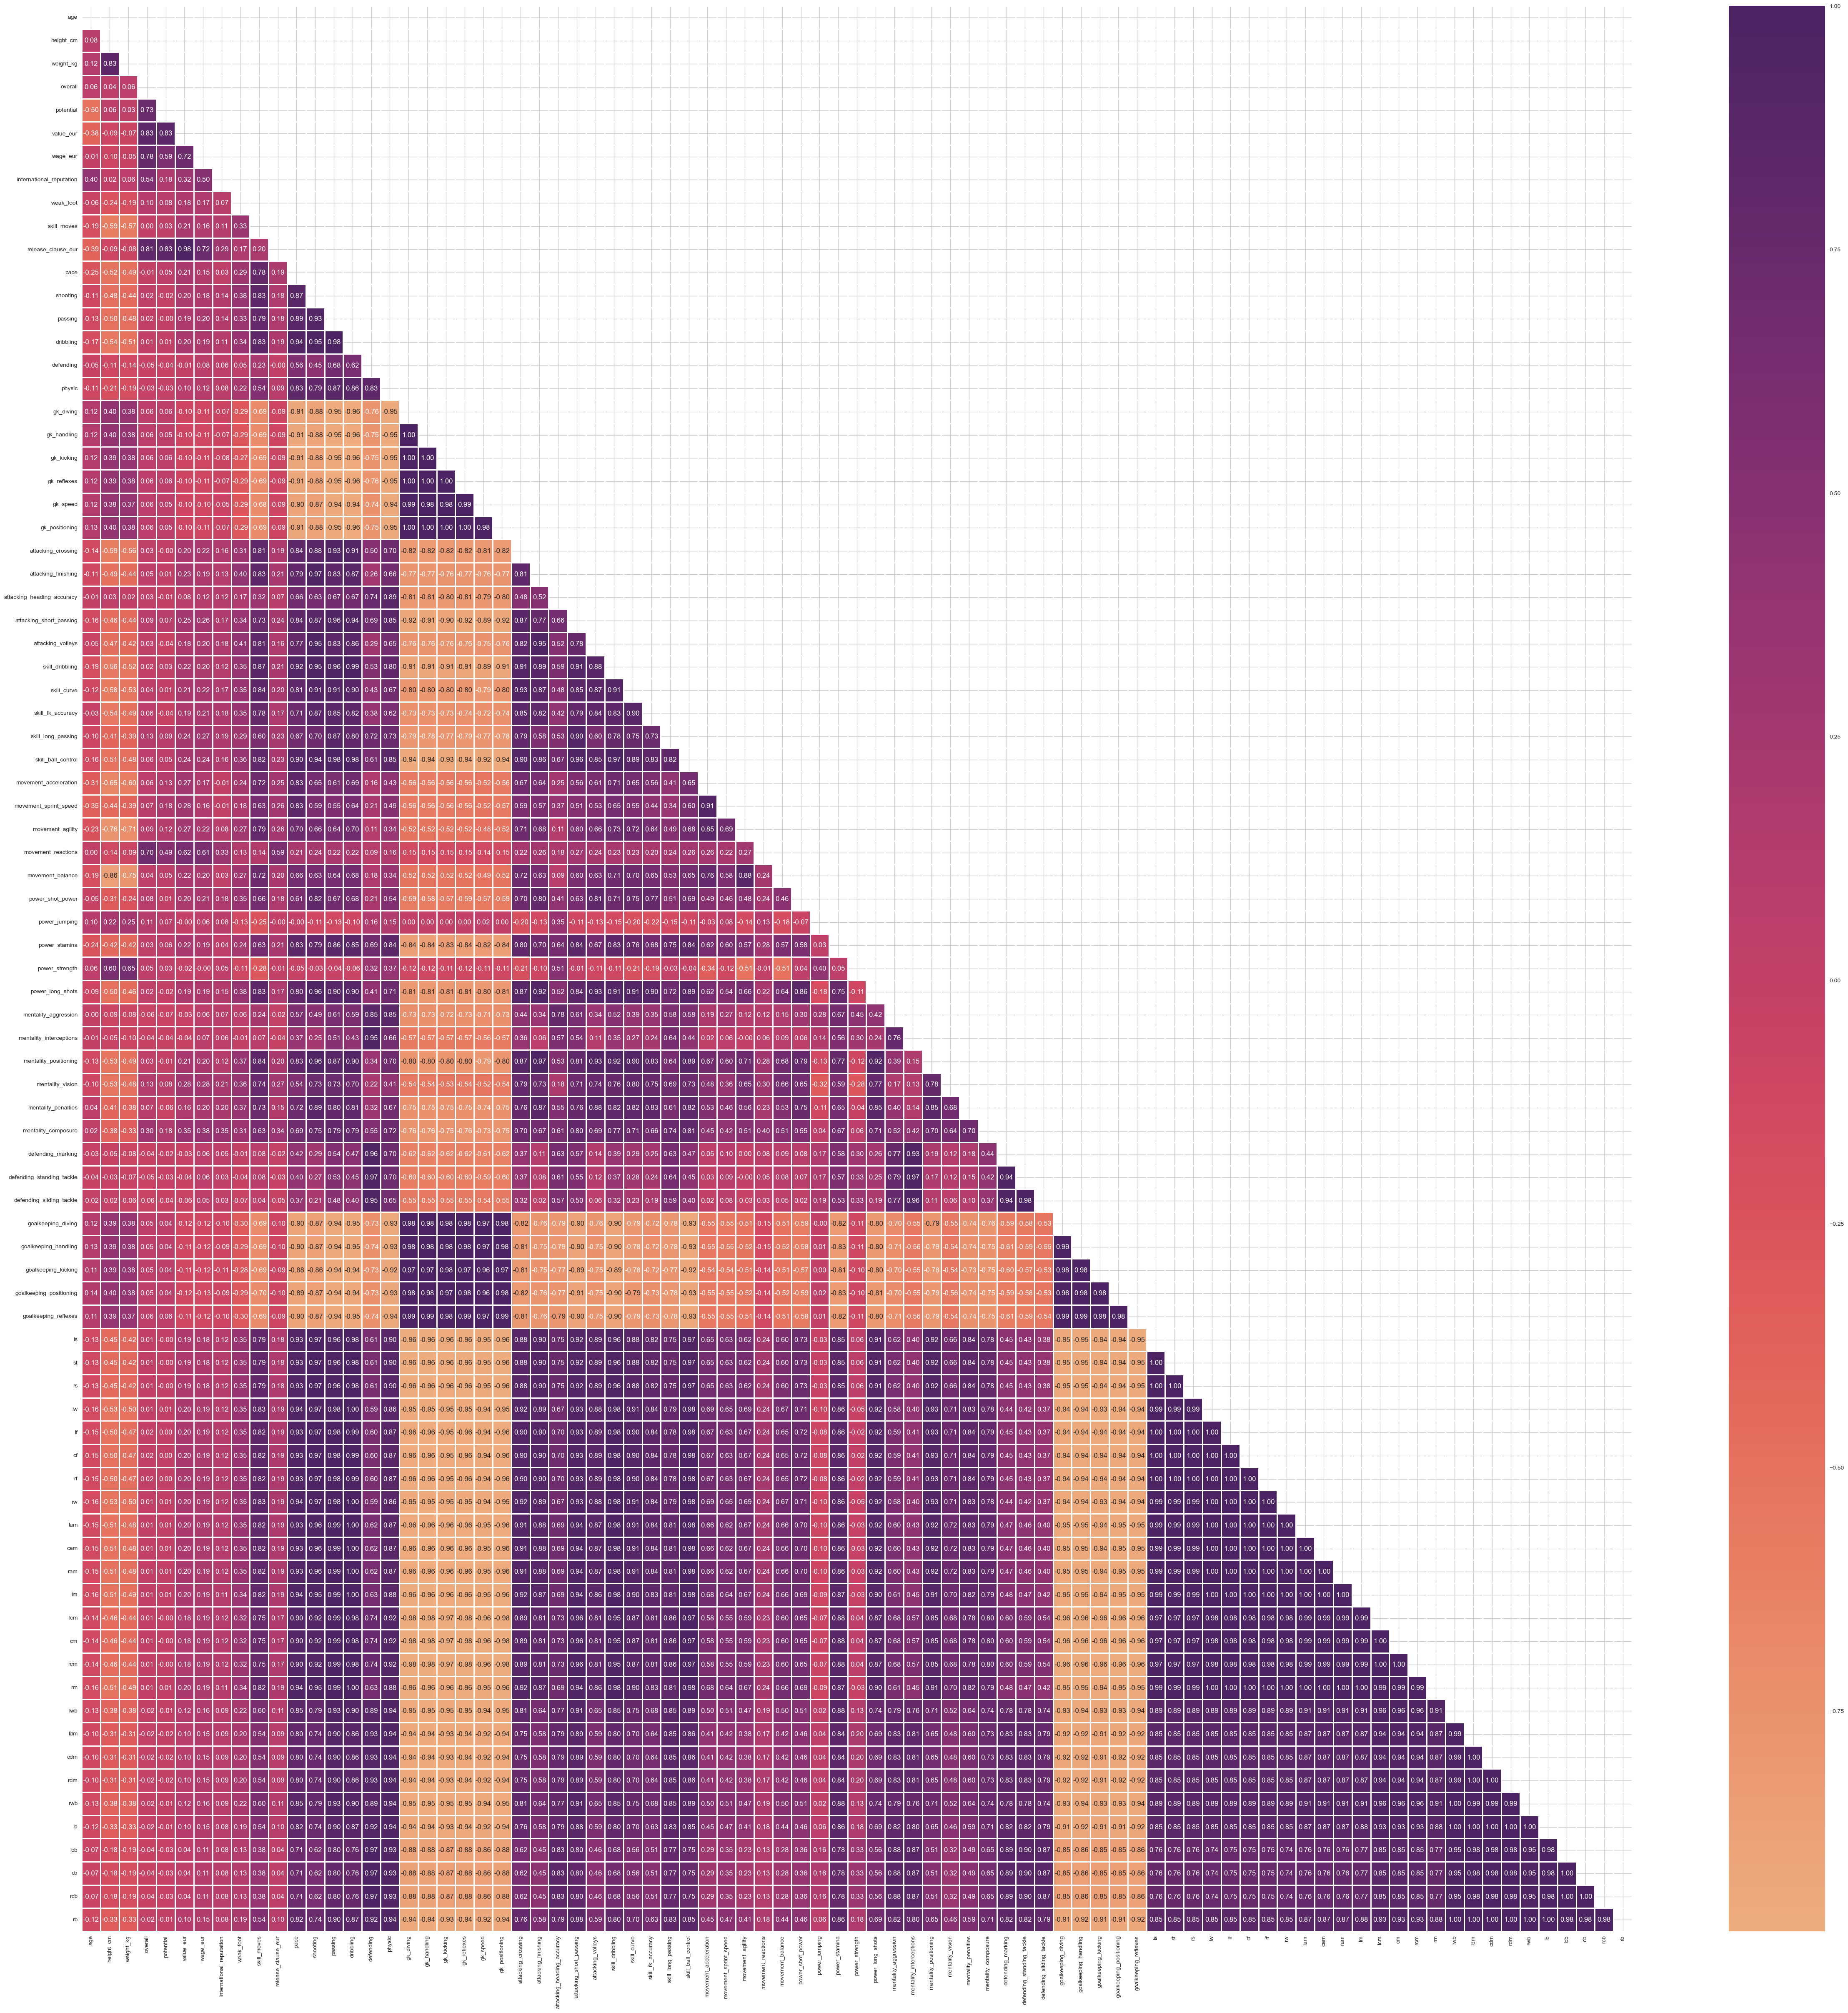

In [32]:
#correlation
corr= fifa_num_imputed.corr()
mask=np.triu(np.ones_like(corr, dtype=bool))

#heatmap
plt.figure(figsize=(60,60))
sns.heatmap(fifa_num_imputed.corr(), mask=mask, center=0, cmap='flare', linewidths=1, annot=True, fmt='.2f');

We can clearly see there are multiple attributes which are strongly correlated with each other. We will get rid of it as they are conveying same information as their related attributes. We have some valuable tools like PCA and t-SNE to reduce the dimension of the dataset and visualise the pattern in lower dimention.

### Scaling

In [34]:
scaler=StandardScaler()
fifa_scaled=scaler.fit_transform(fifa_num_imputed)

### Principle Component Analysis

In [35]:
pca=PCA()
fifa_pca=pca.fit_transform(fifa_scaled)
pca_comp=PCA(n_components=2)
fifa_pca=pca_comp.fit_transform(fifa_scaled)
#concatenating with original dataset
col_names=['PC1', 'PC2']
new_fifa=pd.concat([fifa_num_imputed.reset_index(drop=True), pd.DataFrame(fifa_pca, columns=col_names)], axis=1)
new_fifa['player_name']=fifa['short_name']
new_fifa.head(3)

,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,skill_moves,...,rdm,rwb,lb,lcb,cb,rcb,rb,PC1,PC2,player_name
0,32,170,72,94,94,95500000,565000,5,4,4,...,66,68,63,52,52,52,63,6.286130,-6.857673,L. Messi
1,34,187,83,93,93,58500000,405000,5,4,5,...,61,65,61,53,53,53,61,5.181026,-4.763143,Cristiano Ronaldo
2,27,175,68,92,92,105500000,290000,5,5,5,...,61,66,61,46,46,46,61,5.337898,-7.370628,Neymar Jr


## Task 2

### Clustering

KMeans clustering is a popular unsupervised machine learning algorithm used for grouping similar data points together. The algorithm works by partitioning a dataset into a predetermined number of clusters, where each cluster represents a group of similar data points.

In this project, we will explore the use of KMeans clustering in grouping FIFA players based on their attributes and positions. We will use the algorithm to identify clusters of similar players and analyze the characteristics of each cluster. By doing so, we can gain insights into the distribution and performance of players across different positions and attribute categories.

#### Elbow Method
In the next part, we will be performing the "Elbow Method" to determine the optimal number of clusters for KMeans clustering. The Elbow Method is a graphical technique used to select the number of clusters by observing the relationship between the number of clusters and the Within-Cluster-Sum-of-Squares (WCSS) value.

We will iterate over a range of values for k (the number of clusters) and calculate the WCSS value for each k using KMeans clustering. We will then plot the WCSS values against the number of clusters, and look for a point in the plot where the decrease in WCSS begins to level off. This point is referred to as the "Elbow Point", and it indicates the optimal number of clusters for the dataset.

We will also add vertical lines on the plot to help visualize the Elbow Point, and annotate the plot to indicate the Elbow Region. By using the Elbow Method, we can choose the optimal number of clusters for our KMeans clustering algorithm, and use it to cluster FIFA players based on their attributes and positions.

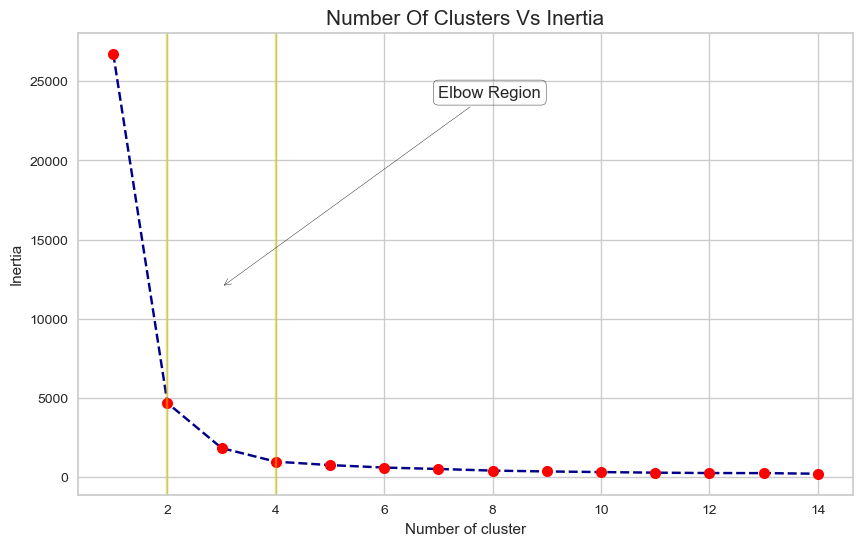

In [37]:
wcss=[]

for k in range(1,15):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(fifa_pca)
    inertia=kmeans.inertia_
    wcss.append(inertia)

#plotting graph
plt.figure(figsize=(10,6))
plt.plot(range(1,15), wcss, color='darkblue',linestyle='dashed', marker='o',markerfacecolor='red', markersize=8)
plt.axvline(2, alpha=0.5, color='y')
plt.axvline(4, alpha=0.5, color='y')
plt.annotate('Elbow Region', (3, 12000), (7, 24000),
            arrowprops=dict(arrowstyle="->",connectionstyle="Arc3", color="k"),
            bbox = dict(boxstyle = "round", fc ="none", ec="k"))
plt.xlabel('Number of cluster')
plt.ylabel('Inertia')
plt.title('Number of clusters vs Inertia'.title(), fontsize=15);

Similar to the above plot we can also visualise optimum value of clusters using the KElbowVisualizer from the yellowbrick library. The plot shows the relationship between the number of clusters and the within-cluster sum of squares (inertia) of the data. The optimal number of clusters is where the decrease in inertia starts to slow down and forms an elbow shape in the plot.



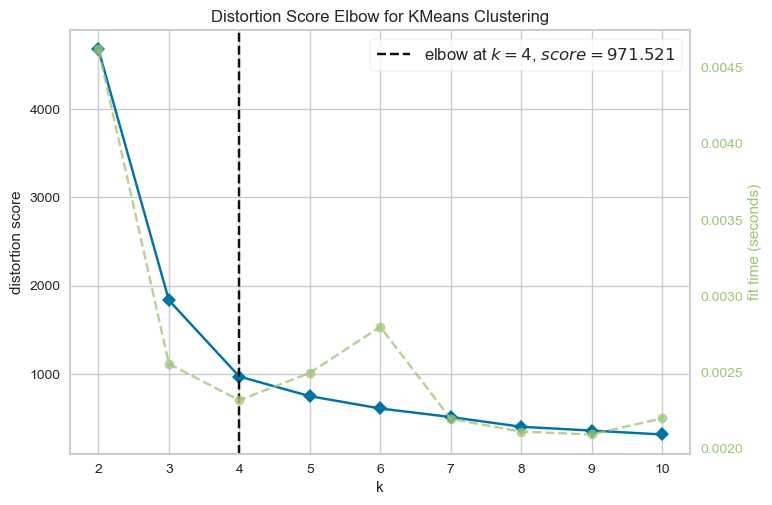

In [38]:
visualizer3 = KElbowVisualizer(KMeans(), k=(2,11))

visualizer3.fit(fifa_pca) # Fit the data to the visualizer
visualizer3.show(outpath='elbowplot2.png');


We have got a visual where Elbow can be. The bend occurs at clusters 2. But the wcss becomes more stable after clusters 4.

In [39]:
# KMeans model
clusterer = KMeans(n_clusters=4, n_init="auto", random_state=10)
cluster_labels = clusterer.fit_predict(fifa_pca)

# Silhouette score
silhouette_avg = silhouette_score(fifa_pca, cluster_labels)
print(
    "For n_clusters =",
    4,
    "The average silhouette_score is :",
    silhouette_avg,
)

For n_clusters = 4 The average silhouette_score is : 0.5659393303801895


we can observe that the clustering with 4 clusters has the highest silhouette score of 0.56, indicating lower silhouette scores, indicating that the data points are overlapping or are not well-matched to their own clusters.

It is important to note that the silhouette score alone may not provide a complete picture of the quality of the clustering. In some cases, a lower silhouette score may still correspond to good clustering, especially when the clusters are well-separated and clearly distinct from each other.

In [48]:
def plot_clusters(num_clusters):
    
    kmeans=KMeans(n_clusters=num_clusters, init='k-means++', random_state=42)
    kmeans.fit(fifa_pca)
    #Adding labels to new_fifa dataframe
    new_fifa['labels']=kmeans.labels_

    sub_data=new_fifa[new_fifa['overall']>80]
    plt.figure(figsize=(20,15))
    sns.scatterplot(sub_data, x='PC1', y='PC2', hue='labels', palette='tab10')

    for index, row in new_fifa.iterrows():
        if row['overall']>85:
            plt.annotate(row['player_name'], xy=(row['PC1'], row['PC2']), xytext=(row['PC1']+1, row['PC2']+1), textcoords='offset points',
                ha='left', va='top', fontsize=12, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7), 
                arrowprops=None)

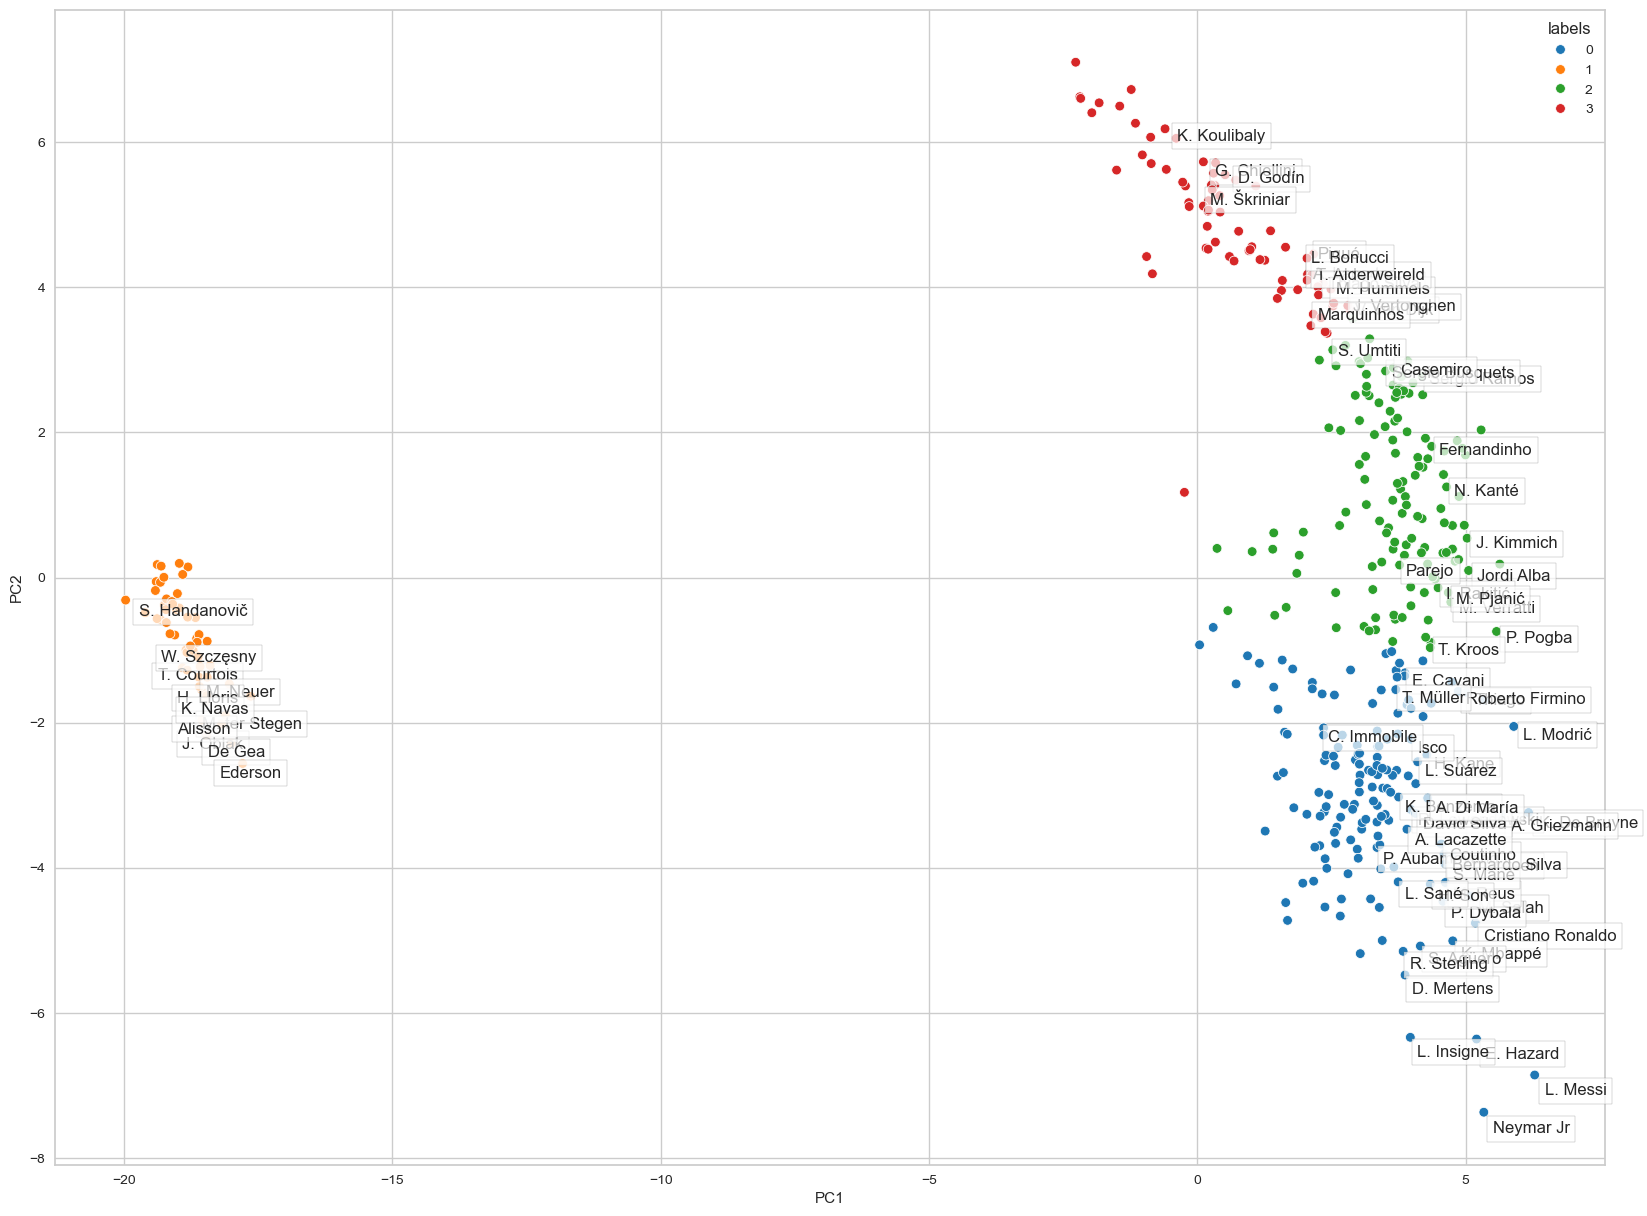

In [49]:
plot_clusters(4)

The model appears to be working well with 4 clusters. The clusters are distinguished with the help of colors. Upon analysing, we can observe following points:

- Blue cluster represents likes to play in more attacking players, mostly strikers and attacking mid-fielders.
- Green cluster represents players likes playing in center part of pitch and create chances throught their passing abilities.
- Red cluster represents Defenders protecting their goal.
- Orange cluster represents Goalkeepers standing like a wall to nullify any attempt of opposition to score goals.

## Basic and EDA
The dataset contained 18278 player records and 104 features. The dataset is considerably large and had lot of missing data and wrong data types. These challenges were taken care of during the data processing part. We have also created additional functions to webscrap the image url from the sofifa website from where the whole dataset was scrapped.

We started by preparing a rank-ordered list of the top 10 countries with the most players. The top 3 countries with the most players were England, Germany, and Spain, and they produced the most footballers at this level.

We then plotted the distribution of overall rating vs. age of players, which showed that players tend to reach their peak around the age of 27, after which their overall rating starts to decline. This implies that players' performance deteriorates as they age.

We explored which type of offensive players tends to get paid the most. The position of center forward tends to be the most highly paid among offensive players, with an average wage of 51,714 euros per week. This is followed by the left wing and right wing positions.

The data shows no significant difference in market value or wage between right-footed and left-footed players, indicating that preferred foot does not have a major impact on a player's value or earnings.

The average budget to form a competitive football team is 230 million euros.

## Clusteing model & Techniques
In order to explore football skills and cluster football players based on their attributes, we first selected players with an overall rating of more than a certain threshold for each mode for better visualisation and to remove noise. We then applied StandardScaler and PCA to the dataset, before applying clustering techniques.

In the modelling part, we used K-Means to visualize the cluster

Clustering offered by all of these techniques were observed to be done on the same attribute. ie. Playing position

There are two obvious clusters: Goalkeepers and Non-goalkeepers

For Non-goalkeepers, the players are again grouped into 3 categories, those who play in more advanced role (Strikers and attacking midfielders), those who plays in the middle of the pitch and players playing in defensive postions.

We have noticed that the clusering is not 100% clean as there are some overlapping. It may be again because of the playing style and attributes of players. For example, defender like Sergio Ramos who is more aggressive and likes to play in advance position more often, has higher attacking attributes than other defenders. Such defensive players might be plotted higher in the plot.

To determine the optimal number of clusters, we analyzed the elbow plot. The elbow plot suggested that 2 clusters were suitable, but we also observed that the wcss became more stable after 4 clusters. Silhouette scores showed that clustering with 4 clusters had the Low silhouette score of 0.56, indicating lower silhouette scores, indicating that the data points are overlapping or are not well-matched to their own clusters. However, it is important to note that the silhouette score alone may not provide a complete picture of the quality of clustering.

Overall, clustering was successful in clustering players based on their playing positions, and could be used to gain insights into the different skills and attributes required for different positions on the football field.

